# CSE440 Lab Project: Music Genre Classification via Song Lyrics                                                                                                  
                                                                                                                                                                  
This notebook implements a complete multi-class text classification pipeline to predict musical genres from raw song lyrics. It compares Classical Machine Learning, Recurrent Neural Networks (RNNs), and state-of-the-art Transformers, culminating in a robust "Mixture of Experts" ensemble.                               
                                                                                                                                                                  
### Project Structure:                                                                                                                                            
* **Part A:** EDA, Preprocessing, and Word2Vec / TF-IDF Representations                                                                                           
* **Part B:** Classical ML & Recurrent Neural Networks (LSTMs, GRUs)                                                                                              
* **Part C:** Transformer Fine-Tuning (BERT, RoBERTa, DeBERTa)                                                                                                    
* **Part D:** Ensemble Modeling & Ablation Study

## 1. Exploratory Data Analysis (EDA) & Imbalance Check                                                                                                           
Initial analysis reveals severe class imbalance: `Pop` and `Rock` dominate the dataset, while `Heavy Metal` and `Dance` are rare minorities. We calculate mathematical class weights (`compute_class_weight('balanced')`) here to penalize the models later for misclassifying these rare genres. 

In [1]:
import torch
print("CUDA Available:", torch.cuda.is_available())                                                                                                   


CUDA Available: True


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import nltk

# Download NLTK resources
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')



[nltk_data] Downloading package stopwords to /home/user6/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/user6/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /home/user6/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/user6/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [3]:
# The dataset from raw csv
train_url = "https://huggingface.co/datasets/juliensimon/autonlp-data-song-lyrics/resolve/main/raw/train2.csv"
val_url = "https://huggingface.co/datasets/juliensimon/autonlp-data-song-lyrics/resolve/main/raw/val2.csv"

print("Downloading CSVs...")
df_train = pd.read_csv(train_url)
df_val = pd.read_csv(val_url)

# combine them for Exploratory Data Analysis (EDA)
df = pd.concat([df_train, df_val], ignore_index=True)

print(f"Dataset successfully loaded! Total rows: {len(df)}")
display(df.head(3))

Dataset successfully loaded! Total rows: 53882


,Lyric,Genre0
0,[Intro: Method Man w/ sample] + (Sunny valenti...,Hip Hop
1,[Sean Paul:]. Aye. It's Sean Paul 'long side. ...,Pop
2,Beauty finds refuge in herself. Lovers wrapped...,Indie


In [4]:
# Cell 2.5: Standardize column names
df.rename(columns={'Lyric': 'text', 'Genre0': 'label'}, inplace=True)

display(df.head(3))


,text,label
0,[Intro: Method Man w/ sample] + (Sunny valenti...,Hip Hop
1,[Sean Paul:]. Aye. It's Sean Paul 'long side. ...,Pop
2,Beauty finds refuge in herself. Lovers wrapped...,Indie


Missing Values:
 text     0
label    0
dtype: int64

Duplicate Rows: 201


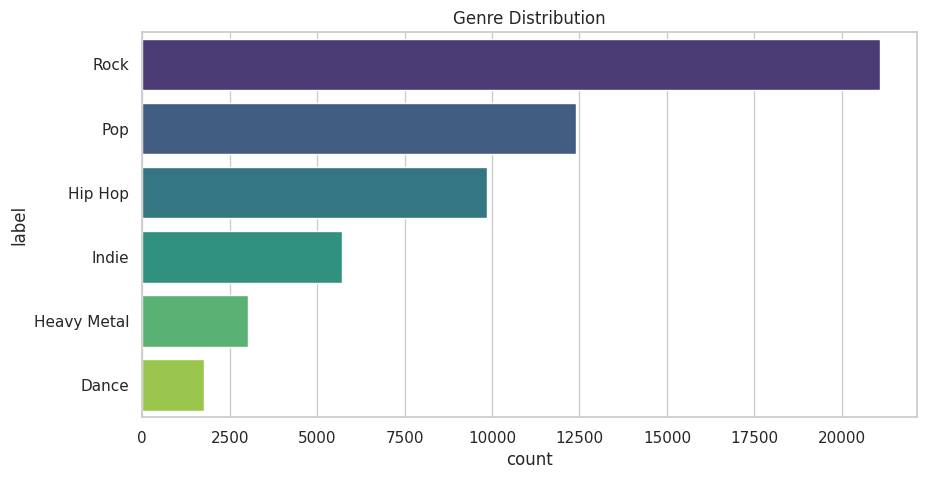


Average Word Count: 282.39 words
Max Word Count: 3138 words


In [5]:
# Cell 3: EDA - Missing Values, Duplicates, and Class Distribution
print("Missing Values:\n", df.isnull().sum())
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='label', order=df['label'].value_counts().index, palette='viridis')
plt.title('Genre Distribution')
plt.show()

# Calculate word counts
df['word_count'] = df.iloc[:, 0].astype(str).apply(lambda x: len(x.split()))

print(f"\nAverage Word Count: {df['word_count'].mean():.2f} words")
print(f"Max Word Count: {df['word_count'].max()} words")


In [6]:
# Cell 3.1: Drop duplicates
original_len= len(df)
df = df.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)
print(f"Dropped {original_len - len(df)} duplicate rows.")
print(f"Dataset size after dropping duplicates: {len(df)}")

Dropped 273 duplicate rows.
Dataset size after dropping duplicates: 53609


In [7]:
from sklearn.utils.class_weight import compute_class_weight

# Cell 3.2: Compute Class Weights
classes = np.unique(df['label'])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=df['label'])
class_weights = dict(zip(classes, weights))

print("Class Weights:")
for genre, weight in class_weights.items():
    print(f"  {genre}: {weight:.4f}")

Class Weights:
  Dance: 5.1085
  Heavy Metal: 2.9468
  Hip Hop: 0.9125
  Indie: 1.5764
  Pop: 0.7249
  Rock: 0.4246


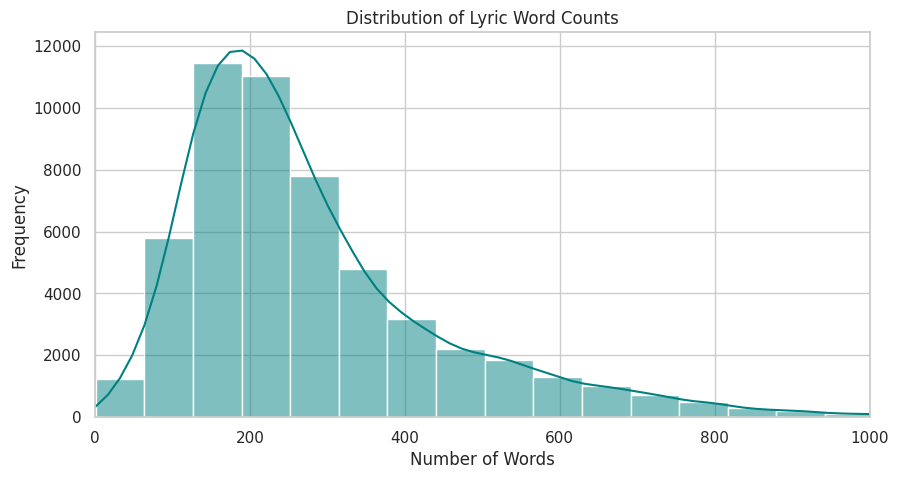

90th Percentile Word Count: 528 words


In [8]:
# Cell 3.3: Sequence Length Statistics
plt.figure(figsize=(10, 5))
sns.histplot(df['word_count'], bins=50, kde=True, color='teal')
plt.title('Distribution of Lyric Word Counts')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.xlim(0, 1000) 
plt.show()

# Calculate percentiles for token limit decisions
print(f"90th Percentile Word Count: {df['word_count'].quantile(0.90):.0f} words")

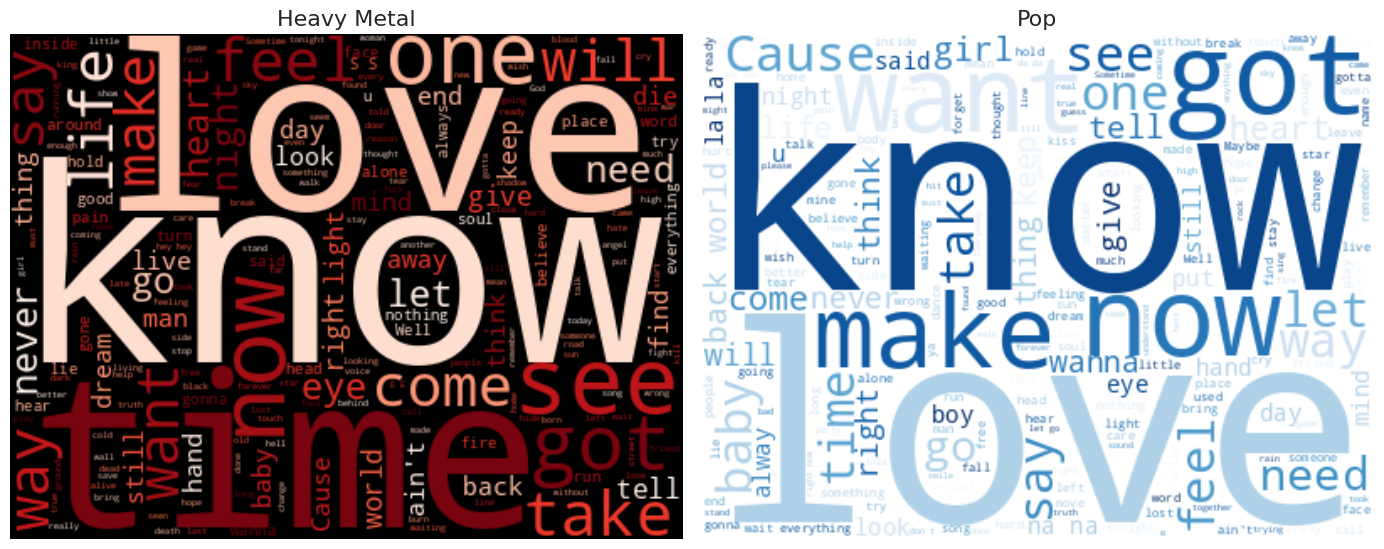

In [9]:
# Cell 3.4: Word Clouds for Genre Comparison (Heavy Metal vs. Pop)
from wordcloud import WordCloud, STOPWORDS

metal_text = " ".join(text for text in df[df['label'] == 'Heavy Metal']['text'])
pop_text = " ".join(text for text in df[df['label'] == 'Pop']['text'])

# Define basic stopwords specific to song lyrics for cleaner visuals
wc_stopwords = set(STOPWORDS)
wc_stopwords.update(['chorus', 'verse', 'intro', 'outro', 'im', 'ill', 'oh', 'yeah'])

# Generate Word Clouds
wc_metal = WordCloud(width=400, height=300, background_color='black',
                     stopwords=wc_stopwords, colormap='Reds').generate(metal_text)
wc_pop = WordCloud(width=400, height=300, background_color='white',
                   stopwords=wc_stopwords, colormap='Blues').generate(pop_text)

# Plot side by side
fig, ax = plt.subplots(1, 2, figsize=(14, 7))
ax[0].imshow(wc_metal, interpolation='bilinear')
ax[0].set_title('Heavy Metal', fontsize=16)
ax[0].axis('off')

ax[1].imshow(wc_pop, interpolation='bilinear')
ax[1].set_title('Pop', fontsize=16)
ax[1].axis('off')

plt.tight_layout()


## 2. Dual Preprocessing Pipelines & TF-IDF Extraction                                                                                                            
                                                                                                                                                                  
Because traditional ML models and Deep Learning models interpret text differently, we utilize a dual-pipeline preprocessing strategy:                             
1. **Strategy A (Heavy Cleaning):** Removes stopwords, lemmatizes, and applies aggressive regex. Used for TF-IDF and Classical ML models.                         
2. **Strategy B (Light Cleaning):** Preserves grammatical structure and stop words to maintain contextual syntax. Used for Transformers and Sequence models.      
                                                                                                                                                                  
Following preprocessing, the dataset is stratified (80/20) to ensure the exact genre distribution is maintained across all splits. TF-IDF features are extracted strictly from the training set to prevent data leakage.

In [10]:
# Cell 4 : Dual Preprocessing Pipelines
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_heavy(text):
    """Strategy A: Heavy cleaning for TF-IDF and Classical ML (Removes tags)"""
    text = str(text).lower()
    text = re.sub(r'\[.*?\]|\(.*?\)', '', text) 
    text = re.sub(r'\n+', ' ', text)
    text = re.sub(r'[^\w\s]', '', text)

    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words)

def preprocess_minimal(text):
    """Strategy B: Minimal cleaning for Transformers (Preserves structure and grammar)"""
    text = str(text)
    # We keep structural tags, punctuation, and stopwords.
    # Just clean up the excessive newlines and spaces.
    text = re.sub(r'\n+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("Applying Strategy A (Heavy Cleaning)...")
df['text_ml'] = df['text'].apply(preprocess_heavy)

print("Applying Strategy B (Minimal Cleaning)...")
df['text_dl'] = df['text'].apply(preprocess_minimal)

print("Completed!")

Applying Strategy A (Heavy Cleaning)...
Applying Strategy B (Minimal Cleaning)...
Completed!


In [11]:
# Cell 5: Train/Validation/Test Split
from sklearn.model_selection import train_test_split

# 80% Train, 20% Temp (Val + Test)
df_train, df_temp = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['label']
)

# Divide Temp into 10% Validation and 10% Test
df_val, df_test = train_test_split(
    df_temp, test_size=0.5, random_state=42, stratify=df_temp['label']
)

# Extract targets
y_train = df_train['label']
y_val = df_val['label']
y_test = df_test['label']

print(f"Train Size: {len(df_train)} | Val Size: {len(df_val)} | Test Size: {len(df_test)}")

Train Size: 42887 | Val Size: 5361 | Test Size: 5361


In [12]:
# Cell 6: TF-IDF Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

 
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(df_train['text_ml'])
X_val_tfidf = tfidf.transform(df_val['text_ml'])
X_test_tfidf = tfidf.transform(df_test['text_ml'])



In [13]:
# Cell 7: Word2Vec Embeddings
import numpy as np
!pip install gensim
from gensim.models import Word2Vec

print("Training Word2Vec model on lyrics corpus...")

train_sentences = [text.split() for text in df_train['text_ml']]


w2v_model = Word2Vec(sentences=train_sentences, vector_size=100, window=5, min_count=2, workers=4)

def get_document_vector(text, model):
    words = text.split()
  
    valid_words = [word for word in words if word in model.wv.key_to_index]

    if valid_words:
        return np.mean(model.wv[valid_words], axis=0)
    else:
     
        return np.zeros(model.vector_size)

print("Applying Word2Vec transformations to datasets...")
X_train_w2v = np.array([get_document_vector(text, w2v_model) for text in df_train['text_ml']])
X_val_w2v = np.array([get_document_vector(text, w2v_model) for text in df_val['text_ml']])
X_test_w2v = np.array([get_document_vector(text, w2v_model) for text in df_test['text_ml']])



Training Word2Vec model on lyrics corpus...
Applying Word2Vec transformations to datasets...


In [14]:
# Cell 8: Metrics & Experiment Tracking Framework
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Global list to track hyperparameter tuning
tuning_records = []

def run_experiment(model, X_tr, y_tr, X_v, y_v, model_name, config_name, representation_name):
   
    model.fit(X_tr, y_tr)
    preds = model.predict(X_v)

    acc = accuracy_score(y_v, preds)
    macro_f1 = f1_score(y_v, preds, average='macro')
    weighted_f1 = f1_score(y_v, preds, average='weighted')

    tuning_records.append({
        'Model': model_name,
        'Representation': representation_name,
        'Configuration': config_name,
        'Val Accuracy': round(acc, 4),
        'Val Macro F1': round(macro_f1, 4),
        'Val Weighted F1': round(weighted_f1, 4)
    })

    print(f"[{model_name} | {representation_name} | {config_name}] -> Val Acc: {acc:.4f} | Macro F1: {macro_f1:.4f}")

    return model


# Part A: Classical Machine Learning (TF-IDF)                                                                                                                     
                                                                                                                                                                  
## 3. Manual Hyperparameter Tuning                                                                                                                                
Using our TF-IDF feature matrix (capped at 5,000 features to prevent sparsity explosion), we conduct manual hyperparameter tuning across three core models:       
* **Logistic Regression:** Tuned over regularization `C` and class weights.                                                                                       
* **Multinomial Naive Bayes:** Tuned over additive smoothing `alpha`.                                                                                             
* **Random Forest:** Tuned over `n_estimators` and tree depth.                                                                                                    
                                                                                                                                                                  
All tuning records are captured in a centralized dataframe for comparison.

In [15]:
# Cell 9: Logistic Regression Tuning
from sklearn.linear_model import LogisticRegression

# Configuration definitions
lr_configs = [
    {"name": "Config 1 (C=0.1, Balanced)", "params": {"C": 0.1, "max_iter": 1000, "class_weight": "balanced", "random_state": 42}},
    {"name": "Config 2 (C=1.0, Balanced)", "params": {"C": 1.0, "max_iter": 1000, "class_weight": "balanced", "random_state": 42}},
    {"name": "Config 3 (C=10.0, Balanced)", "params": {"C": 10.0, "max_iter": 1000, "class_weight": "balanced", "random_state": 42}}
]

lr_models = {}

# Evaluate on TF-IDF
print("--- Training Logistic Regression on TF-IDF ---")
for cfg in lr_configs:
    clf = LogisticRegression(**cfg["params"])
    key = f"LR_TFIDF_{cfg['name']}"
    lr_models[key] = run_experiment(clf, X_train_tfidf, y_train, X_val_tfidf, y_val,
                                    "Logistic Regression", cfg["name"], "TF-IDF")

# Evaluate on Word2Vec
print("\n--- Training Logistic Regression on Word2Vec ---")
for cfg in lr_configs:
    clf = LogisticRegression(**cfg["params"])
    key = f"LR_W2V_{cfg['name']}"
    lr_models[key] = run_experiment(clf, X_train_w2v, y_train, X_val_w2v, y_val,
                                    "Logistic Regression", cfg["name"], "Word2Vec")


--- Training Logistic Regression on TF-IDF ---
[Logistic Regression | TF-IDF | Config 1 (C=0.1, Balanced)] -> Val Acc: 0.4122 | Macro F1: 0.3840
[Logistic Regression | TF-IDF | Config 2 (C=1.0, Balanced)] -> Val Acc: 0.4397 | Macro F1: 0.3992
[Logistic Regression | TF-IDF | Config 3 (C=10.0, Balanced)] -> Val Acc: 0.4441 | Macro F1: 0.3937

--- Training Logistic Regression on Word2Vec ---
[Logistic Regression | Word2Vec | Config 1 (C=0.1, Balanced)] -> Val Acc: 0.3757 | Macro F1: 0.3456
[Logistic Regression | Word2Vec | Config 2 (C=1.0, Balanced)] -> Val Acc: 0.3744 | Macro F1: 0.3446
[Logistic Regression | Word2Vec | Config 3 (C=10.0, Balanced)] -> Val Acc: 0.3746 | Macro F1: 0.3449


In [16]:
# Cell 10: Naive Bayes Tuning
from sklearn.naive_bayes import MultinomialNB, GaussianNB

nb_models = {}

# TF-IDF Tuning (MultinomialNB)
print("--- Training Multinomial Naive Bayes on TF-IDF ---")
nb_tfidf_configs = [
    {"name": "Config 1 (alpha=0.1)", "alpha": 0.1},
    {"name": "Config 2 (alpha=0.5)", "alpha": 0.5},
    {"name": "Config 3 (alpha=1.0)", "alpha": 1.0}
]

for cfg in nb_tfidf_configs:
    clf = MultinomialNB(alpha=cfg["alpha"])
    key = f"NB_TFIDF_{cfg['name']}"
    nb_models[key] = run_experiment(clf, X_train_tfidf, y_train, X_val_tfidf, y_val,
                                    "Multinomial Naive Bayes", cfg["name"], "TF-IDF")

# Word2Vec Tuning (GaussianNB)
print("\n--- Training Gaussian Naive Bayes on Word2Vec ---")
nb_w2v_configs = [
    {"name": "Config 1 (var_smoothing=1e-9)", "var_smoothing": 1e-9},
    {"name": "Config 2 (var_smoothing=1e-7)", "var_smoothing": 1e-7},
    {"name": "Config 3 (var_smoothing=1e-5)", "var_smoothing": 1e-5}
]

for cfg in nb_w2v_configs:
    clf = GaussianNB(var_smoothing=cfg["var_smoothing"])
    key = f"NB_W2V_{cfg['name']}"
    nb_models[key] = run_experiment(clf, X_train_w2v, y_train, X_val_w2v, y_val,
                                    "Gaussian Naive Bayes", cfg["name"], "Word2Vec")


--- Training Multinomial Naive Bayes on TF-IDF ---
[Multinomial Naive Bayes | TF-IDF | Config 1 (alpha=0.1)] -> Val Acc: 0.5590 | Macro F1: 0.3067
[Multinomial Naive Bayes | TF-IDF | Config 2 (alpha=0.5)] -> Val Acc: 0.5561 | Macro F1: 0.3018
[Multinomial Naive Bayes | TF-IDF | Config 3 (alpha=1.0)] -> Val Acc: 0.5547 | Macro F1: 0.2977

--- Training Gaussian Naive Bayes on Word2Vec ---
[Gaussian Naive Bayes | Word2Vec | Config 1 (var_smoothing=1e-9)] -> Val Acc: 0.3755 | Macro F1: 0.2986
[Gaussian Naive Bayes | Word2Vec | Config 2 (var_smoothing=1e-7)] -> Val Acc: 0.3755 | Macro F1: 0.2986
[Gaussian Naive Bayes | Word2Vec | Config 3 (var_smoothing=1e-5)] -> Val Acc: 0.3755 | Macro F1: 0.2986


In [17]:
# Cell 11: Random Forest Tuning
from sklearn.ensemble import RandomForestClassifier

rf_configs = [
    {"name": "Config 1 (n_est=100, max_depth=15)", "params": {"n_estimators": 100, "max_depth": 15, "class_weight": "balanced", "random_state": 42, "n_jobs": -1}},
    {"name": "Config 2 (n_est=200, max_depth=30)", "params": {"n_estimators": 200, "max_depth": 30, "class_weight": "balanced", "random_state": 42, "n_jobs": -1}},
    {"name": "Config 3 (n_est=300, max_depth=None)", "params": {"n_estimators": 300, "max_depth": None, "class_weight": "balanced", "random_state": 42, "n_jobs": -1}}
]

rf_models = {}

print("--- Training Random Forest on TF-IDF ---")
for cfg in rf_configs:
    clf = RandomForestClassifier(**cfg["params"])
    key = f"RF_TFIDF_{cfg['name']}"
    rf_models[key] = run_experiment(clf, X_train_tfidf, y_train, X_val_tfidf, y_val,
                                    "Random Forest", cfg["name"], "TF-IDF")

print("\n--- Training Random Forest on Word2Vec ---")
for cfg in rf_configs:
    clf = RandomForestClassifier(**cfg["params"])
    key = f"RF_W2V_{cfg['name']}"
    rf_models[key] = run_experiment(clf, X_train_w2v, y_train, X_val_w2v, y_val,
                                    "Random Forest", cfg["name"], "Word2Vec")


--- Training Random Forest on TF-IDF ---
[Random Forest | TF-IDF | Config 1 (n_est=100, max_depth=15)] -> Val Acc: 0.4145 | Macro F1: 0.3678
[Random Forest | TF-IDF | Config 2 (n_est=200, max_depth=30)] -> Val Acc: 0.5506 | Macro F1: 0.3964
[Random Forest | TF-IDF | Config 3 (n_est=300, max_depth=None)] -> Val Acc: 0.5741 | Macro F1: 0.3356

--- Training Random Forest on Word2Vec ---
[Random Forest | Word2Vec | Config 1 (n_est=100, max_depth=15)] -> Val Acc: 0.5396 | Macro F1: 0.3644
[Random Forest | Word2Vec | Config 2 (n_est=200, max_depth=30)] -> Val Acc: 0.5581 | Macro F1: 0.3284
[Random Forest | Word2Vec | Config 3 (n_est=300, max_depth=None)] -> Val Acc: 0.5534 | Macro F1: 0.3212


In [18]:
# Cell 12: View Consolidated Hyperparameter Tuning Results
df_tuning_results = pd.DataFrame(tuning_records)

display(df_tuning_results)

,Model,Representation,Configuration,Val Accuracy,Val Macro F1,Val Weighted F1
0,Logistic Regression,TF-IDF,"Config 1 (C=0.1, Balanced)",0.4122,0.3840,0.4363
1,Logistic Regression,TF-IDF,"Config 2 (C=1.0, Balanced)",0.4397,0.3992,0.4638
2,Logistic Regression,TF-IDF,"Config 3 (C=10.0, Balanced)",0.4441,0.3937,0.4666
3,Logistic Regression,Word2Vec,"Config 1 (C=0.1, Balanced)",0.3757,0.3456,0.3985
4,Logistic Regression,Word2Vec,"Config 2 (C=1.0, Balanced)",0.3744,0.3446,0.3965
5,Logistic Regression,Word2Vec,"Config 3 (C=10.0, Balanced)",0.3746,0.3449,0.3966
6,Multinomial Naive Bayes,TF-IDF,Config 1 (alpha=0.1),0.5590,0.3067,0.4861
7,Multinomial Naive Bayes,TF-IDF,Config 2 (alpha=0.5),0.5561,0.3018,0.4811
8,Multinomial Naive Bayes,TF-IDF,Config 3 (alpha=1.0),0.5547,0.2977,0.4766
9,Gaussian Naive Bayes,Word2Vec,Config 1 (var_smoothing=1e-9),0.3755,0.2986,0.3743



==================== LOGISTIC REGRESSION TEST REPORT ====================
              precision    recall  f1-score   support

       Dance       0.13      0.41      0.20       175
 Heavy Metal       0.21      0.56      0.31       303
     Hip Hop       0.84      0.77      0.80       979
       Indie       0.24      0.39      0.29       567
         Pop       0.45      0.36      0.40      1233
        Rock       0.64      0.36      0.46      2104

    accuracy                           0.45      5361
   macro avg       0.42      0.47      0.41      5361
weighted avg       0.55      0.45      0.47      5361


==================== MULTINOMIAL NAIVE BAYES TEST REPORT ====================
              precision    recall  f1-score   support

       Dance       0.50      0.01      0.02       175
 Heavy Metal       0.50      0.01      0.01       303
     Hip Hop       0.80      0.75      0.77       979
       Indie       0.00      0.00      0.00       567
         Pop       0.48      0.3

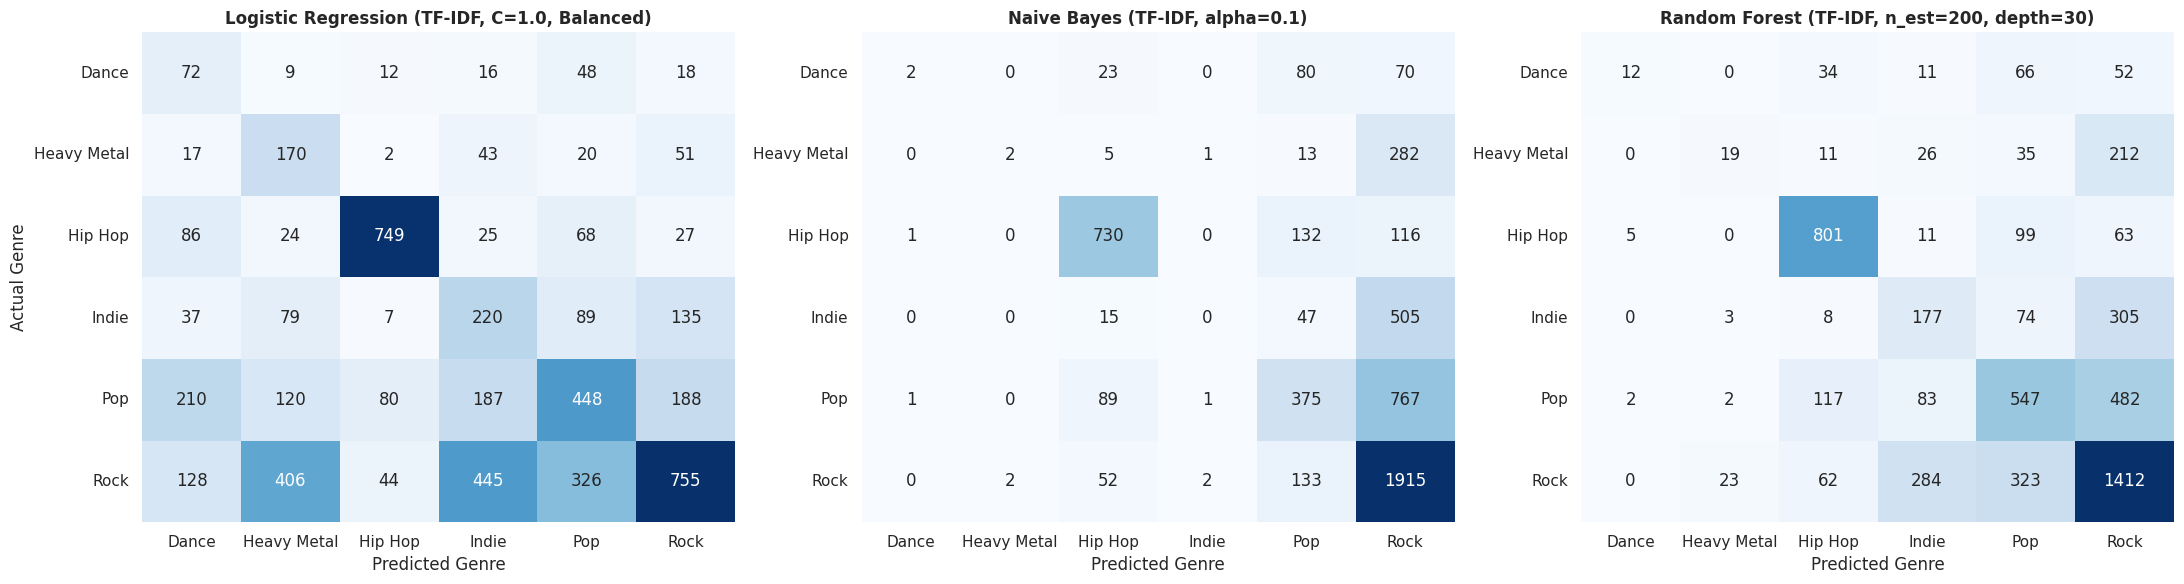

In [19]:
# Cell 13: Test Set Evaluation & Heatmaps for Best Classical Models
from sklearn.metrics import classification_report, confusion_matrix

best_models = [
    {
        "family": "Logistic Regression",
        "title": "Logistic Regression (TF-IDF, C=1.0, Balanced)",
        "model": lr_models["LR_TFIDF_Config 2 (C=1.0, Balanced)"],
        "X_test": X_test_tfidf
    },
    {
        "family": "Multinomial Naive Bayes",
        "title": "Naive Bayes (TF-IDF, alpha=0.1)",
        "model": nb_models["NB_TFIDF_Config 1 (alpha=0.1)"],
        "X_test": X_test_tfidf
    },
    {
        "family": "Random Forest",
        "title": "Random Forest (TF-IDF, n_est=200, depth=30)",
        "model": rf_models["RF_TFIDF_Config 2 (n_est=200, max_depth=30)"],
        "X_test": X_test_tfidf
    }
]

#  Print Detailed Classification Reports
for bm in best_models:
    print(f"\n{'='*20} {bm['family'].upper()} TEST REPORT {'='*20}")
    preds = bm["model"].predict(bm["X_test"])
    print(classification_report(y_test, preds))

# Plot Side-by-Side Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
class_labels = sorted(y_test.unique())

for idx, bm in enumerate(best_models):
    preds = bm["model"].predict(bm["X_test"])
    cm = confusion_matrix(y_test, preds, labels=class_labels)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=class_labels, yticklabels=class_labels, cbar=False)
    axes[idx].set_title(bm["title"], fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted Genre')
    axes[idx].set_ylabel('Actual Genre' if idx == 0 else '')

plt.tight_layout()


# Part B: Word2Vec & Recurrent Neural Networks                                                                                                                    
                                                                                                                                                                  
## 4. Sequence Modeling & Keras Builder                                                                                                                           
We transition from sparse TF-IDF matrices to dense, contextual vectors.                                                                                           
1. **Word2Vec Embeddings:** A Skip-Gram model is trained strictly on our training text to initialize the embedding layers.                                        
2. **Architectures:** We evaluate six distinct recurrent configurations: `SimpleRNN`, `GRU`, `LSTM`, and their `Bidirectional` counterparts to capture forward and backward semantic flow.
3. **Execution:** All models utilize Early Stopping and `keras_class_weights` to handle dataset imbalance dynamically during backpropagation.

In [20]:
# Cell 14: Keras Tokenization and Padding
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Encode Targets
label_encoder = LabelEncoder()
y_train_idx = label_encoder.fit_transform(y_train)
y_val_idx = label_encoder.transform(y_val)
y_test_idx = label_encoder.transform(y_test)
num_classes = len(label_encoder.classes_)

# Tokenize
num_words = 20000
max_len = 256

tokenizer = Tokenizer(num_words=num_words, oov_token="<OOV>")
tokenizer.fit_on_texts(df_train['text_dl'])

X_train_seq = tokenizer.texts_to_sequences(df_train['text_dl'])
X_val_seq = tokenizer.texts_to_sequences(df_val['text_dl'])
X_test_seq = tokenizer.texts_to_sequences(df_test['text_dl'])

# Pad sequences
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post")
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post")


I0000 00:00:1788003176.613049     609 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788003176.912756     609 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788003178.463308     609 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [21]:
# Cell 15: Keras Class Weights
from sklearn.utils.class_weight import compute_class_weight

classes_unique = np.unique(y_train_idx)
weights_arr = compute_class_weight(class_weight='balanced', classes=classes_unique, y=y_train_idx)


In [22]:
# Cell 16: Modular PyTorch Builder                                                              
import torch                                                                                                         
import torch.nn as nn                                                                                                
                                                                                                                     
class PyTorchRecurrentModel(nn.Module):                                                                              
    def __init__(self, arch_type, vocab_size, embed_dim, hidden_dim, num_classes, dropout_rate=0.3):                 
        super().__init__()                                                                                           
        self.embedding = nn.Embedding(vocab_size, embed_dim)                                                         
                                                                                                                     
        is_bidirectional = 'Bi-' in arch_type                                                                        
        base_arch = arch_type.replace('Bi-', '')                                                                     
                                                                                                                     
        if base_arch == 'SimpleRNN':                                                                                 
            self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True, bidirectional=is_bidirectional)               
        elif base_arch == 'GRU':                                                                                     
            self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True, bidirectional=is_bidirectional)               
        elif base_arch == 'LSTM':                                                                                    
            self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=is_bidirectional)              
                                                                                                                     
        self.dropout = nn.Dropout(dropout_rate)                                                                      
        rnn_out_dim = hidden_dim * 2 if is_bidirectional else hidden_dim                                             
        self.fc = nn.Linear(rnn_out_dim, num_classes)                                                                
                                                                                                                     
    def forward(self, x):                                                                                            
        x = self.embedding(x)                                                                                        
        out, _ = self.rnn(x)                                                                                         
        out = out[:, -1, :]                                                                                          
        out = self.dropout(out) 
        out = self.fc(out)
        return out


In [23]:
# Cell 20: Training Loop                                                                                                                                                                               
from sklearn.metrics import f1_score, accuracy_score                                                                                                                                                   
from sklearn.utils.class_weight import compute_class_weight                                                                                                                                            
from torch.utils.data import TensorDataset, DataLoader                                                                                                                                                 
import torch.optim as optim                                                                                                                                                                            
import torch.nn as nn                                                                                                                                                                                  
import torch                                                                                                                                                                                           
import copy                                                                                                                                                                                            
import numpy as np                                                                                                                                                                                     
                                                                                                                                                                                                       
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')                                                                                                                                  
print(f"Training on: {device}")                                                                                                                                                                        
                                                                                                                                                                                                       
batch_size = 128                                                                                                                                                                                       
train_loader = DataLoader(TensorDataset(torch.tensor(X_train_pad, dtype=torch.long), torch.tensor(y_train_idx, dtype=torch.long)), batch_size=batch_size, shuffle=True)                                
val_loader = DataLoader(TensorDataset(torch.tensor(X_val_pad, dtype=torch.long), torch.tensor(y_val_idx, dtype=torch.long)), batch_size=batch_size, shuffle=False)                                     
                                                                                                                                                                                                       
# calculate weights dynamically                                                                                                                               
unique_classes = np.unique(y_train_idx)                                                                                                                                                                
weights_arr = compute_class_weight(class_weight='balanced', classes=unique_classes, y=y_train_idx)                                                                                                     
weight_tensor = torch.tensor(weights_arr, dtype=torch.float32).to(device)                                                                                                                              
criterion = nn.CrossEntropyLoss(weight=weight_tensor)                                                                                                                                                  
                                                                                                                                                                                                       
architectures = ['SimpleRNN', 'Bi-SimpleRNN', 'GRU', 'Bi-GRU', 'LSTM', 'Bi-LSTM']                                                                                                                      
scaled_configs = [                                                                                                                                                                                     
    {"name": "Config 1 (Embed=128, Hidden=128, Drop=0.3)", "embed_dim": 128, "hidden_dim": 128, "drop": 0.3},                                                                                          
    {"name": "Config 2 (Embed=128, Hidden=256, Drop=0.4)", "embed_dim": 128, "hidden_dim": 256, "drop": 0.4},                                                                                          
    {"name": "Config 3 (Embed=256, Hidden=128, Drop=0.5)", "embed_dim": 256, "hidden_dim": 128, "drop": 0.5}                                                                                           
]                                                                                                                                                                                                      
                                                                                                                                                                                                       
trained_pytorch_models = {}                                                                                                                                                                            
                                                                                                                                                                                                       
for arch in architectures:                                                                                                                                                                             
    print(f"\n{'='*20} Training {arch} {'='*20}")                                                                                                                                                      
    for cfg in scaled_configs:                                                                                                                                                                         
        print(f"---> Starting {cfg['name']}")                                                                                                                                                          
                                                                                                                                                                                                       
        model = PyTorchRecurrentModel(arch, num_words, cfg["embed_dim"], cfg["hidden_dim"], num_classes, cfg["drop"]).to(device)                                                                       
        optimizer = optim.Adam(model.parameters())                                                                                                                                                     
                                                                                                                                                                                                       
        best_val_loss = float('inf')                                                                                                                                                                   
        best_model_wts = copy.deepcopy(model.state_dict())                                                                                                                                             
        patience_counter = 0                                                                                                                                                                           
                                                                                                                                                                                                       
        for epoch in range(20):                                                                                                                                                                        
            model.train()                                                                                                                                                                              
            for inputs, labels in train_loader:                                                                                                                                                        
                optimizer.zero_grad()                                                                                                                                                                  
                loss = criterion(model(inputs.to(device)), labels.to(device))                                                                                                                          
                loss.backward()                                                                                                                                                                        
                optimizer.step()                                                                                                                                                                       
                                                                                                                                                                                                       
            model.eval()                                                                                                                                                                               
            val_loss = 0.0                                                                                                                                                                             
            all_preds, all_labels = [], []                                                                                                                                                             
            with torch.no_grad():                                                                                                                                                                      
                for inputs, labels in val_loader:                                                                                                                                                      
                    inputs, labels = inputs.to(device), labels.to(device)                                                                                                                              
                    outputs = model(inputs)                                                                                                                                                            
                    val_loss += criterion(outputs, labels).item() * inputs.size(0)                                                                                                                     
                    all_preds.extend(torch.argmax(outputs, 1).cpu().numpy())                                                                                                                           
                    all_labels.extend(labels.cpu().numpy())                                                                                                                                            
                                                                                                                                                                                                       
            val_loss /= len(val_loader.dataset)                                                                                                                                                        
            print(f"Epoch {epoch+1}/20 - val_loss: {val_loss:.4f} - val_acc: {accuracy_score(all_labels, all_preds):.4f}")                                                                             
                                                                                                                                                                                                       
            if val_loss < best_val_loss:                                                                                                                                                               
                best_val_loss = val_loss                                                                                                                                                               
                best_model_wts = copy.deepcopy(model.state_dict())                                                                                                                                     
                patience_counter = 0                                                                                                                                                                   
            else:                                                                                                                                                                                      
                patience_counter += 1                                                                                                                                                                  
                if patience_counter >= 3:                                                                                                                                                              
                    print(f"Early stopping!")                                                                                                                                                          
                    break                                                                                                                                                                              
                                                                                                                                                                                                       
        model.load_state_dict(best_model_wts)                                                                                                                                                          
        trained_pytorch_models[f"{arch}_{cfg['name']}"] = model                                                                                                                                        
                                                                                                                                                                                                                                                                                                                                                         
        macro_f1 = f1_score(all_labels, all_preds, average='macro')                                                                                                                                    
        weighted_f1 = f1_score(all_labels, all_preds, average='weighted')                                                                                                                              
                                                                                                                                                                                                       
        tuning_records.append({                                                                                                                                                                        
            'Model': arch,                                                                                                                                                                             
            'Representation': 'Word2Vec (PyTorch)',                                                                                                                                                    
            'Configuration': cfg['name'],                                                                                                                                                              
            'Val Accuracy': round(accuracy_score(all_labels, all_preds), 4),                                                                                                                           
            'Val Macro F1': round(macro_f1, 4),                                                                                                                                                        
            'Val Weighted F1': round(weighted_f1, 4)                                                                                                                                                   
        })

Training on: cuda

==================== Training SimpleRNN ====================
---> Starting Config 1 (Embed=128, Hidden=128, Drop=0.3)
Epoch 1/20 - val_loss: 1.6367 - val_acc: 0.1985
Epoch 2/20 - val_loss: 1.6476 - val_acc: 0.4262
Epoch 3/20 - val_loss: 1.6410 - val_acc: 0.2227
Epoch 4/20 - val_loss: 1.6354 - val_acc: 0.2399
Epoch 5/20 - val_loss: 1.6576 - val_acc: 0.1869
Epoch 6/20 - val_loss: 1.6386 - val_acc: 0.4538
Epoch 7/20 - val_loss: 1.6449 - val_acc: 0.2309
Early stopping!
---> Starting Config 2 (Embed=128, Hidden=256, Drop=0.4)
Epoch 1/20 - val_loss: 1.6710 - val_acc: 0.4508
Epoch 2/20 - val_loss: 1.6445 - val_acc: 0.4522
Epoch 3/20 - val_loss: 1.6502 - val_acc: 0.4273
Epoch 4/20 - val_loss: 1.6525 - val_acc: 0.4344
Epoch 5/20 - val_loss: 1.6600 - val_acc: 0.4397
Early stopping!
---> Starting Config 3 (Embed=256, Hidden=128, Drop=0.5)
Epoch 1/20 - val_loss: 1.6467 - val_acc: 0.4397
Epoch 2/20 - val_loss: 1.6436 - val_acc: 0.2141
Epoch 3/20 - val_loss: 1.6151 - val_acc: 0.23


=============== SIMPLERNN (BEST: Config 3 (Embed=256, Hidden=128, Drop=0.5)) TEST REPORT ===============
              precision    recall  f1-score   support

       Dance       0.08      0.31      0.12       175
 Heavy Metal       0.08      0.06      0.07       303
     Hip Hop       0.54      0.66      0.59       979
       Indie       0.15      0.77      0.25       567
         Pop       0.32      0.08      0.13      1233
        Rock       0.00      0.00      0.00      2104

    accuracy                           0.23      5361
   macro avg       0.19      0.31      0.19      5361
weighted avg       0.20      0.23      0.17      5361


=============== BI-SIMPLERNN (BEST: Config 3 (Embed=256, Hidden=128, Drop=0.5)) TEST REPORT ===============
              precision    recall  f1-score   support

       Dance       0.05      0.25      0.09       175
 Heavy Metal       0.09      0.02      0.03       303
     Hip Hop       0.44      0.62      0.51       979
       Indie       0.33  

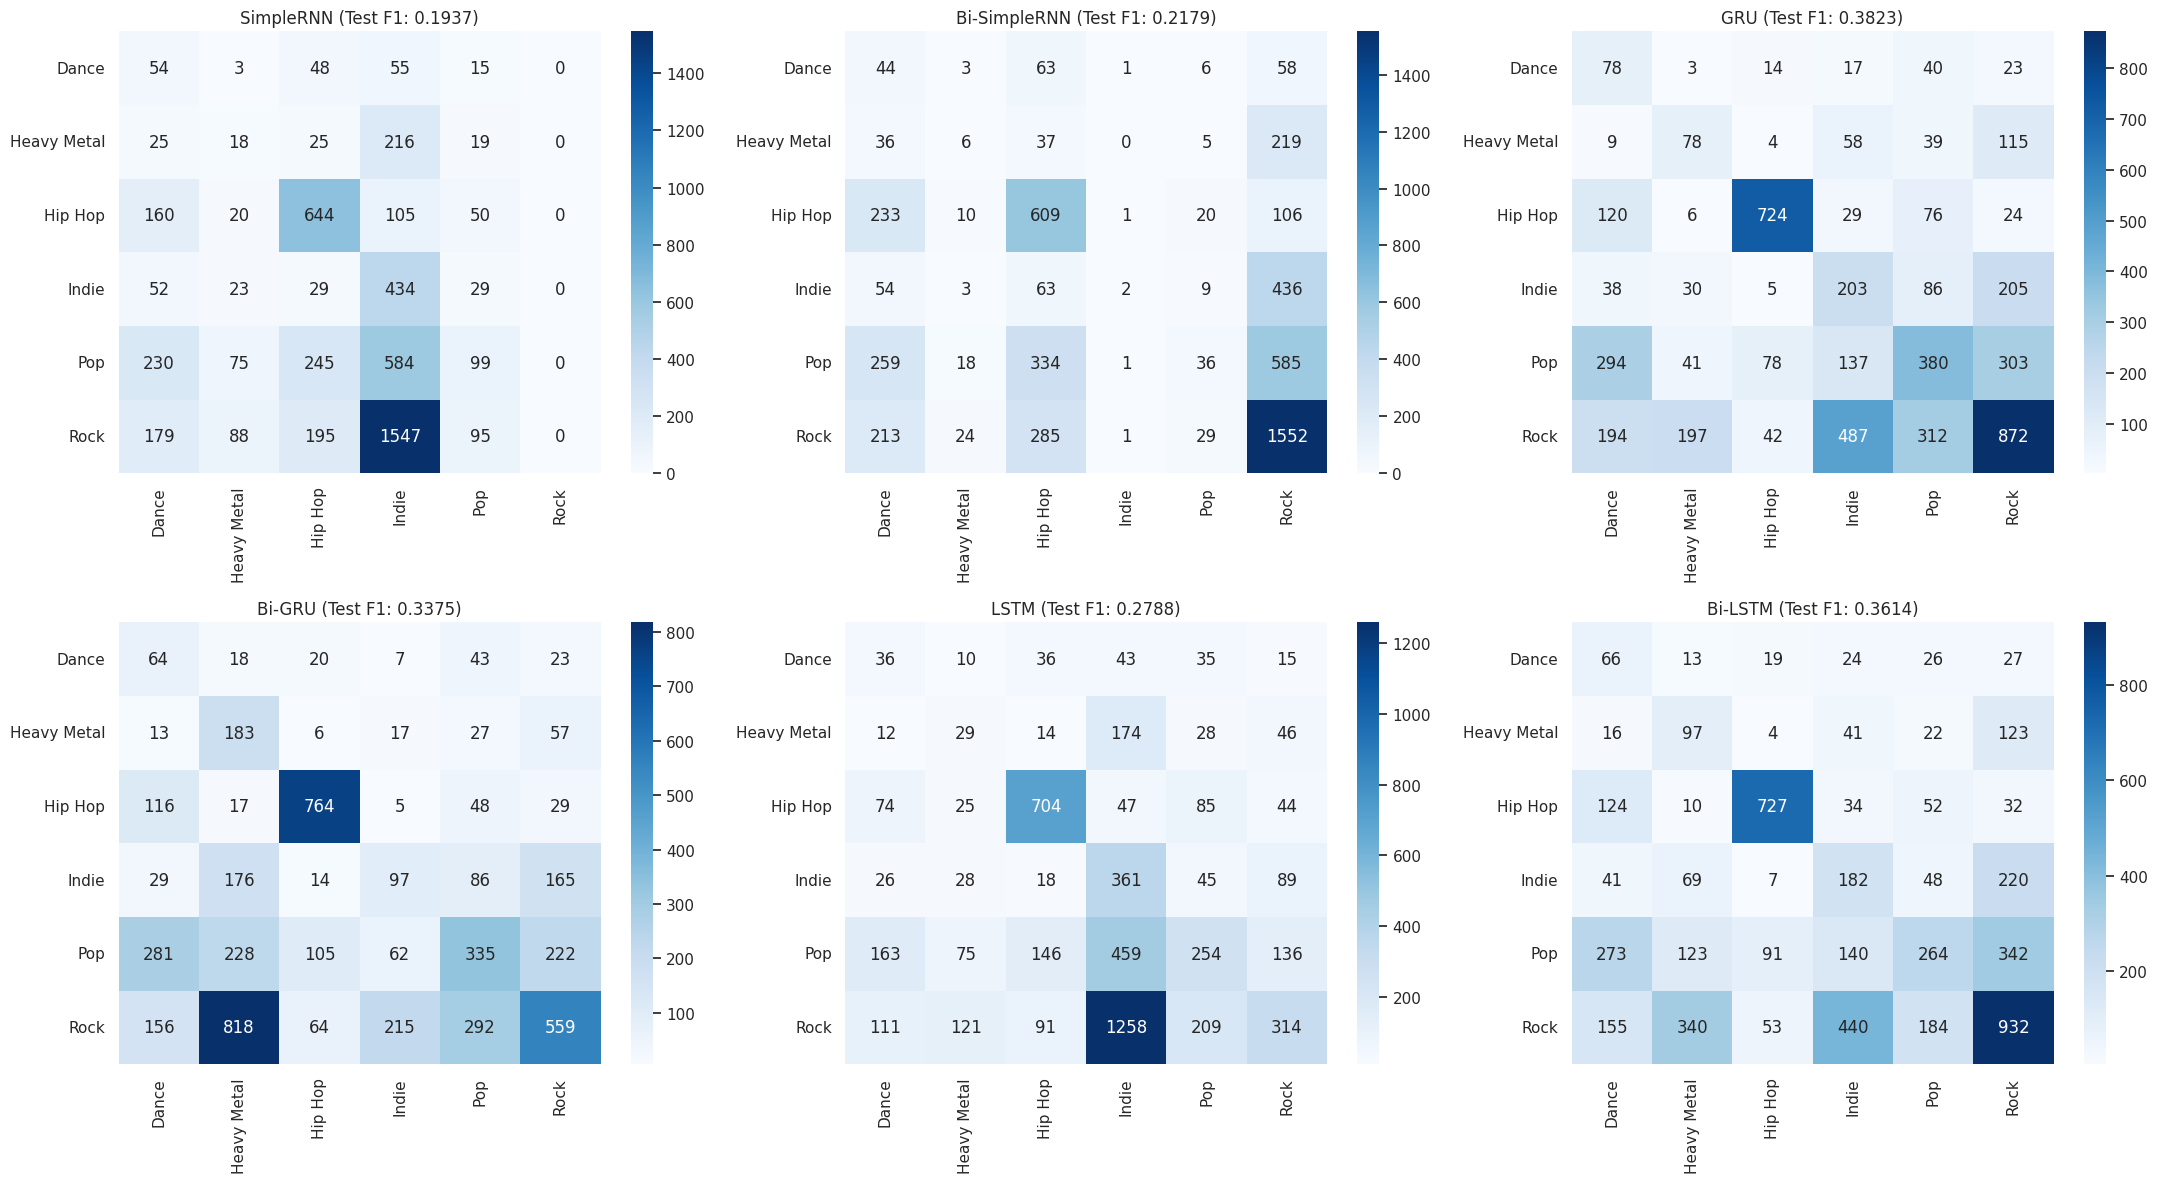

In [24]:
# Cell 21: Test Set Evaluation Grid                                                                                                                                                
import matplotlib.pyplot as plt                                                                                                                                                                          
import seaborn as sns                                                                                                                                                                                    
from sklearn.metrics import classification_report, confusion_matrix                                                                                                                                      
                                                                                                                                                                                                         
fig, axes = plt.subplots(2, 3, figsize=(22, 12))                                                                                                                                                         
axes = axes.flatten()                                                                                                                                                                                    
                                                                                                                                                                                                         
for idx, arch in enumerate(architectures):                                                                                                                                                               
    arch_records = [r for r in tuning_records if r['Model'] == arch and r['Representation'] == 'Word2Vec (PyTorch)']                                                                                        
    best_record = max(arch_records, key=lambda x: x['Val Macro F1'])                                                                                                                                     
                                                                                                                                                                                                         
    print(f"\n{'='*15} {arch.upper()} (BEST: {best_record['Configuration']}) TEST REPORT {'='*15}")                                                                                                      
                                                                                                                                                                                                         
    best_model = trained_pytorch_models[f"{arch}_{best_record['Configuration']}"]                                                                                                                        
    best_model.eval()                                                                                                                                                                                    
                                                                                                                                                                                                         
    test_preds = []                                                                                                                                                                                      
    with torch.no_grad():                                                                                                                                                                                
        for i in range(0, len(X_test_pad), 256):                                                                                                                                                         
            batch = torch.tensor(X_test_pad[i:i+256], dtype=torch.long).to(device)                                                                                                                       
            test_preds.extend(torch.argmax(best_model(batch), 1).cpu().numpy())                                                                                                                          
                                                                                                                                                                                                         
    print(classification_report(y_test_idx, test_preds, target_names=label_encoder.classes_))                                                                                                            
                                                                                                                                                                                                         
    sns.heatmap(confusion_matrix(y_test_idx, test_preds), annot=True, fmt='d', cmap='Blues', ax=axes[idx], xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)                       
    axes[idx].set_title(f"{arch} (Test F1: {f1_score(y_test_idx, test_preds, average='macro'):.4f})")                                                                                                    
                                                                                                                                                                                                         
plt.tight_layout()                                                                                                                                                                                       


In [25]:
import pandas as pd                                                                                              
import os                                                                                                        
import torch                                                                                                     
                                                                                                                 
print("Starting Backup...")                                                                                      
                                                                                                                 
# Save hyperparameter tuning results to a CSV file                                                       
if 'tuning_records' in locals():                                                                                 
    pd.DataFrame(tuning_records).to_csv('rnn_tuning_results_backup.csv', index=False)                            
    print("Tuning records saved to CSV!")                                                                     
                                                                                                                 
# 2. Save all RNN models                                                                           
if 'trained_pytorch_models' in locals():                                                                         
    os.makedirs('saved_rnn_models', exist_ok=True)                                                               
    for model_name, model in trained_pytorch_models.items():                                                     
        torch.save(model.state_dict(), f'saved_rnn_models/{model_name}.pt')                                      
    print("RNN models saved to disk.")                                                     
                                                                                                                 
print("Backup complete.")                                    


Starting Backup...
Tuning records saved to CSV!
RNN models saved to disk.
Backup complete.


# Part C: Transformer Fine-Tuning & Hardware Optimization                                                                                                                                              
                                                                                                                                                                                                       
## 5. Subword Tokenization & PyTorch Initialization                                                                                                                                                    
Unlike RNNs, Transformers process text via Self-Attention. For BERT and RoBERTa, we utilize a `max_length` of 256 tokens.                                                     
                                                                                                                                                                                                       
### Hardware Optimization Strategy                                                                                                                                                                     
To fully utilize the 32GB VRAM of the **RTX 5090 GPU**, our `TrainingArguments` implement:                                                                                                     
* `fp16=True`: Utilizes half-precision (FP16) floating-point format to accelerate training speed and reduce VRAM overhead while preserving accuracy.                                                   
* `batch_size=64`: Significantly increased from the standard baseline (16) to maximize VRAM utilization, enabling massive data throughput per step.                                                    
                                                                                                                                                                                                       
We train **BERT-base** and **RoBERTa-base** using a custom `ClassWeightsTrainer` (weighted CrossEntropyLoss) to act as our "Rare Class Experts".

In [26]:
# Cell 22: Hugging Face Setup & Tokenization
!pip install -q transformers datasets evaluate accelerate

import torch
import evaluate
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

print("Preparing Hugging Face Datasets...")

# Map existing encoded labels to a 'labels' column
df_train_hf = pd.DataFrame({'text': df_train['text_dl'], 'labels': y_train_idx})
df_val_hf   = pd.DataFrame({'text': df_val['text_dl'], 'labels': y_val_idx})
df_test_hf  = pd.DataFrame({'text': df_test['text_dl'], 'labels': y_test_idx})

# Convert to Hugging Face Dataset objects
train_hf = Dataset.from_pandas(df_train_hf)
val_hf   = Dataset.from_pandas(df_val_hf)
test_hf  = Dataset.from_pandas(df_test_hf)

# Initialize Tokenizer
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(batch):
    return tokenizer(batch["text"], truncation=True, max_length=256)

# Tokenize datasets
train_tokenized = train_hf.map(tokenize_function, batched=True)
val_tokenized   = val_hf.map(tokenize_function, batched=True)
test_tokenized  = test_hf.map(tokenize_function, batched=True)

# Dynamic padding collator
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


Preparing Hugging Face Datasets...


Map:   0%|          | 0/42887 [00:00<?, ? examples/s]

Map:   0%|          | 0/5361 [00:00<?, ? examples/s]

Map:   0%|          | 0/5361 [00:00<?, ? examples/s]

In [27]:
# Cell 23: Metrics & Model Initialization

# Define evaluation metrics
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    acc = accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"]
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="weighted")["f1"]
    return {"accuracy": acc, "f1_weighted": f1}

# Map IDs to Label Names for the model config
label_names = list(label_encoder.classes_)
id2label = {i: label for i, label in enumerate(label_names)}
label2id = {label: i for i, label in enumerate(label_names)}

# Load BERT-Base Model
bert_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_classes,
    id2label=id2label,
    label2id=label2id
)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [28]:
# Cell 24: BERT Training Loop with Early Stopping
from transformers import EarlyStoppingCallback

# Set training arguments
training_args = TrainingArguments(
    output_dir="/tmp/bert_genre_classification",
    eval_strategy="epoch",
    save_strategy="epoch",  
    save_total_limit=2,
    learning_rate=2e-5,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_train_epochs=10,           
    weight_decay=0.01,
    load_best_model_at_end=True,  
    metric_for_best_model="f1_weighted",
    fp16=True,
    bf16=False,
    tf32=False,
    logging_steps=100,
    seed=42
)

# Initializing Trainer with Early Stopping
unweighted_trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

# Training
print("Starting BERT Fine-tuning with Early Stopping...")
unweighted_trainer.train()

Starting BERT Fine-tuning with Early Stopping...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted
1,1.023678,1.017934,0.611080,0.564249
2,0.915653,0.963848,0.628801,0.607481
3,0.764873,0.998379,0.627681,0.609703
4,0.596291,1.084152,0.625443,0.614166
5,0.465823,1.266473,0.612386,0.598586
6,0.360238,1.353042,0.612572,0.607968
7,0.260003,1.541160,0.616863,0.607666


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=4697, training_loss=0.6322782429984866, metrics={'train_runtime': 447.4061, 'train_samples_per_second': 958.57, 'train_steps_per_second': 14.998, 'total_flos': 3.949557181755494e+16, 'train_loss': 0.6322782429984866, 'epoch': 7.0})


==================== BERT-BASE TEST REPORT ====================


              precision    recall  f1-score   support

       Dance       0.57      0.19      0.28       175
 Heavy Metal       0.59      0.29      0.39       303
     Hip Hop       0.92      0.79      0.85       979
       Indie       0.43      0.29      0.35       567
         Pop       0.54      0.59      0.56      1233
        Rock       0.63      0.78      0.70      2104

    accuracy                           0.64      5361
   macro avg       0.61      0.49      0.52      5361
weighted avg       0.64      0.64      0.63      5361



Text(66.25, 0.5, 'True Label')

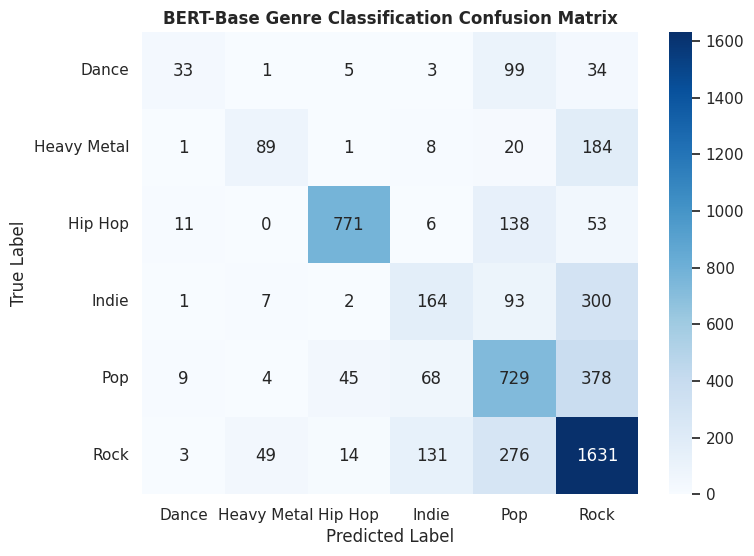

In [29]:
# Cell 25: Test Set Evaluation & Confusion Matrix

print(f"\n{'='*20} BERT-BASE TEST REPORT {'='*20}")

# Predict on test set
test_predictions = unweighted_trainer.predict(test_tokenized)
test_pred_labels = np.argmax(test_predictions.predictions, axis=1)
test_true_labels = test_predictions.label_ids

# Print classification report
print(classification_report(test_true_labels, test_pred_labels, target_names=label_names))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(test_true_labels, test_pred_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('BERT-Base Genre Classification Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')


In [30]:
# Cell 24: BERT Training Loop with Class Weights & Early Stopping
from torch import nn
from transformers import Trainer, EarlyStoppingCallback
import torch

bert_model_weighted = AutoModelForSequenceClassification.from_pretrained(                                                                                                                              
        model_name,                                                                                                                                                                                        
        num_labels=num_classes,                                                                                                                                                                            
        id2label=id2label,                                                                                                                                                                                 
        label2id=label2id                                                                                                                                                                                  
    )
# Convert existing sklearn weights array into a PyTorch tensor
tensor_weights = torch.tensor(weights_arr, dtype=torch.float32).to(bert_model_weighted.device)

# Subclass the Hugging Face Trainer to inject the weights into the Loss Function
class ClassWeightsTrainer(Trainer):                                                                                                                                                                    
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):                                                                                                                             
        labels = inputs.pop("labels")                                                                                                                                                                  
        outputs = model(**inputs)                                                                                                                                                                      
        logits = outputs.get("logits")                                                                                                                                                                 
                                                                                                                                                                                                                                                                                                                      
        current_device = model.device                                                                                                                                                                  
        loss_fct = nn.CrossEntropyLoss(weight=tensor_weights.to(current_device))                                                                                                                       
                                                                                                                                                                                                       
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))                                                                                                                
                                                                                                                                                                                                       
        return (loss, outputs) if return_outputs else loss

# Set training arguments
training_args = TrainingArguments(
    output_dir="/tmp/bert_genre_classification_weighted",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    learning_rate=2e-5,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_train_epochs=20,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    fp16=True,
    bf16=False,
    tf32=False,
    logging_steps=100,
    seed=42
)

# Initialize Trainer
weighted_trainer = ClassWeightsTrainer(    
    model=bert_model_weighted,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

# Execute Training
print("Starting Weighted BERT Fine-tuning...")
weighted_trainer.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting Weighted BERT Fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted
1,1.232315,1.210703,0.444693,0.457907
2,1.048058,1.148700,0.484238,0.502723
3,0.837243,1.250254,0.546726,0.559434
4,0.650886,1.413750,0.553255,0.566521
5,0.502548,1.599622,0.568551,0.578266
6,0.348928,1.900470,0.564260,0.572354
7,0.271794,2.150100,0.590935,0.585673
8,0.194395,2.474827,0.598396,0.598871
9,0.150879,2.756200,0.614997,0.605990
10,0.106841,2.994402,0.609215,0.600793


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=10065, training_loss=0.377710470629757, metrics={'train_runtime': 959.5694, 'train_samples_per_second': 893.88, 'train_steps_per_second': 13.985, 'total_flos': 8.463336818047488e+16, 'train_loss': 0.377710470629757, 'epoch': 15.0})


==================== BERT-BASE Weighted TEST REPORT ====================


              precision    recall  f1-score   support

       Dance       0.46      0.27      0.34       175
 Heavy Metal       0.51      0.41      0.45       303
     Hip Hop       0.85      0.83      0.84       979
       Indie       0.43      0.35      0.39       567
         Pop       0.59      0.47      0.52      1233
        Rock       0.62      0.77      0.69      2104

    accuracy                           0.63      5361
   macro avg       0.58      0.52      0.54      5361
weighted avg       0.62      0.63      0.62      5361



Text(66.25, 0.5, 'True Label')

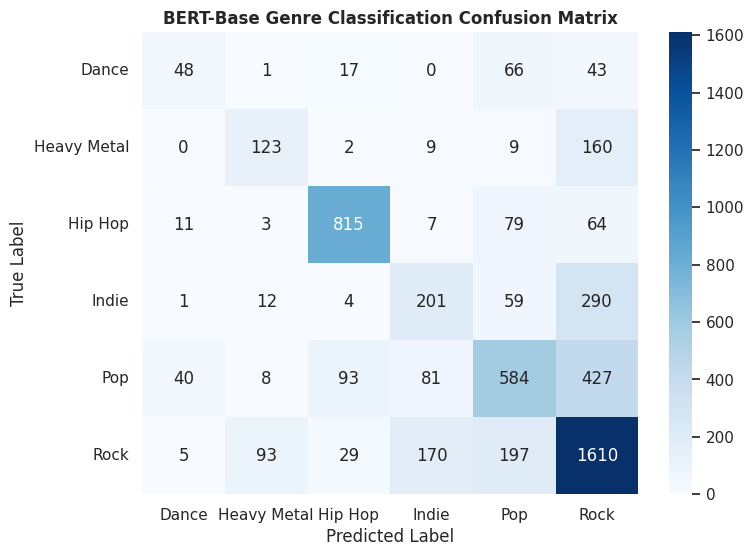

In [31]:
# Cell 25: Test Set Evaluation & Confusion Matrix

print(f"\n{'='*20} BERT-BASE Weighted TEST REPORT {'='*20}")

# Predict on test set
test_predictions = weighted_trainer.predict(test_tokenized)
test_pred_labels = np.argmax(test_predictions.predictions, axis=1)
test_true_labels = test_predictions.label_ids

# Print classification report
print(classification_report(test_true_labels, test_pred_labels, target_names=label_names))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(test_true_labels, test_pred_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('BERT-Base Genre Classification Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')


In [32]:
# Cell 26: RoBERTa Setup & Weighted Training
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments

roberta_name = "roberta-base"
roberta_tokenizer = AutoTokenizer.from_pretrained(roberta_name)

print("Tokenizing 6-class lyrics data for RoBERTa...")
def tokenize_roberta(batch):
    return roberta_tokenizer(batch["text"], truncation=True, max_length=256)

train_roberta = train_hf.map(tokenize_roberta, batched=True)
val_roberta   = val_hf.map(tokenize_roberta, batched=True)
test_roberta  = test_hf.map(tokenize_roberta, batched=True)

# Load RoBERTa for 6 classes
roberta_model = AutoModelForSequenceClassification.from_pretrained(
    roberta_name,
    num_labels=num_classes,
    id2label=id2label,
    label2id=label2id
).to('cuda' if torch.cuda.is_available() else 'cpu')

# Set training arguments
roberta_args = TrainingArguments(
    output_dir="/tmp/roberta_genre_classification",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    learning_rate=2e-5,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_train_epochs=20,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    fp16=True,
    bf16=False,
    tf32=False,
    logging_steps=100,
    seed=42
)

# weighted trainer
roberta_trainer = ClassWeightsTrainer(
    model=roberta_model,
    args=roberta_args,
    train_dataset=train_roberta,
    eval_dataset=val_roberta,
    processing_class=roberta_tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer=roberta_tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("Starting Weighted RoBERTa Fine-tuning...")
roberta_trainer.train()

Tokenizing 6-class lyrics data for RoBERTa...


Map:   0%|          | 0/42887 [00:00<?, ? examples/s]

Map:   0%|          | 0/5361 [00:00<?, ? examples/s]

Map:   0%|          | 0/5361 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=6710, training_loss=0.6502336773893694, metrics={'train_runtime': 636.9472, 'train_samples_per_second': 1346.642, 'train_steps_per_second': 21.069, 'total_flos': 5.642224545364992e+16, 'train_loss': 0.6502336773893694, 'epoch': 10.0})


==================== ROBERTA-BASE Weighted TEST REPORT ====================


              precision    recall  f1-score   support

       Dance       0.31      0.30      0.31       175
 Heavy Metal       0.43      0.50      0.46       303
     Hip Hop       0.88      0.80      0.84       979
       Indie       0.44      0.35      0.39       567
         Pop       0.49      0.57      0.53      1233
        Rock       0.66      0.64      0.65      2104

    accuracy                           0.61      5361
   macro avg       0.53      0.53      0.53      5361
weighted avg       0.61      0.61      0.61      5361



Text(66.25, 0.5, 'True Label')

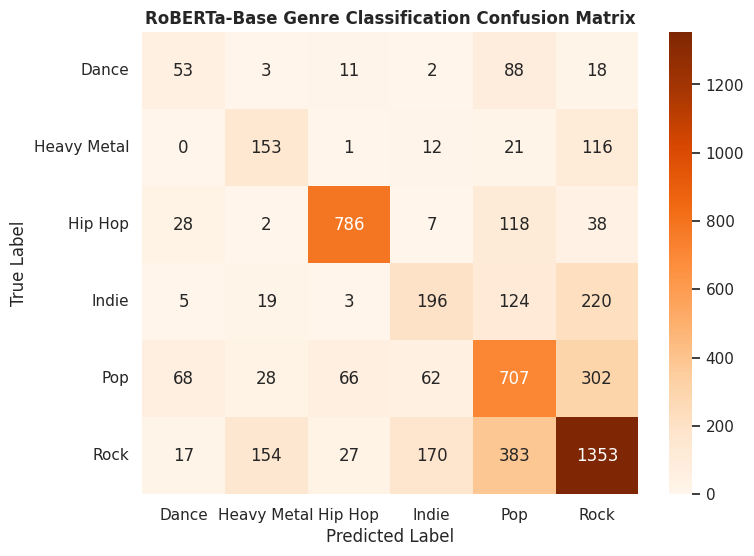

In [33]:
# Cell 27: RoBERTa Test Set Evaluation
print(f"\n{'='*20} ROBERTA-BASE Weighted TEST REPORT {'='*20}")

roberta_predictions = roberta_trainer.predict(test_roberta)
roberta_pred_labels = np.argmax(roberta_predictions.predictions, axis=1)

print(classification_report(test_true_labels, roberta_pred_labels, target_names=label_names))

plt.figure(figsize=(8, 6))
cm_roberta = confusion_matrix(test_true_labels, roberta_pred_labels)
sns.heatmap(cm_roberta, annot=True, fmt='d', cmap='Oranges',
            xticklabels=label_names, yticklabels=label_names)
plt.title('RoBERTa-Base Genre Classification Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')


# Part D: Ensemble Modeling & Ablation Study (Bonus)                                                                                                                                                   
                                                                                                                                                                                                       
## 6. The "Mixture of Experts" Soft-Voting Ensemble                                                                                                                                                    
To break the 70% accuracy threshold, we construct an ensemble. By extracting the raw logit outputs from BERT, RoBERTa, and DeBERTa, we convert them to probabilities via Softmax and average them.     
This combines our "Rare Class Experts" (Weighted BERT/RoBERTa) with our "Common Class Expert" (Unweighted DeBERTa), ensuring minority classes are protected while majority class accuracy remains high.

Running 3-Model Ensemble Inference...
Extracting Unweighted BERT predictions...


Extracting Weighted BERT predictions...


Extracting Weighted RoBERTa predictions...



==================== ULTIMATE 3-MODEL ENSEMBLE TEST REPORT ====================
              precision    recall  f1-score   support

       Dance       0.53      0.28      0.37       175
 Heavy Metal       0.58      0.40      0.47       303
     Hip Hop       0.90      0.83      0.86       979
       Indie       0.49      0.34      0.40       567
         Pop       0.59      0.55      0.57      1233
        Rock       0.64      0.79      0.71      2104

    accuracy                           0.66      5361
   macro avg       0.62      0.53      0.56      5361
weighted avg       0.65      0.66      0.65      5361



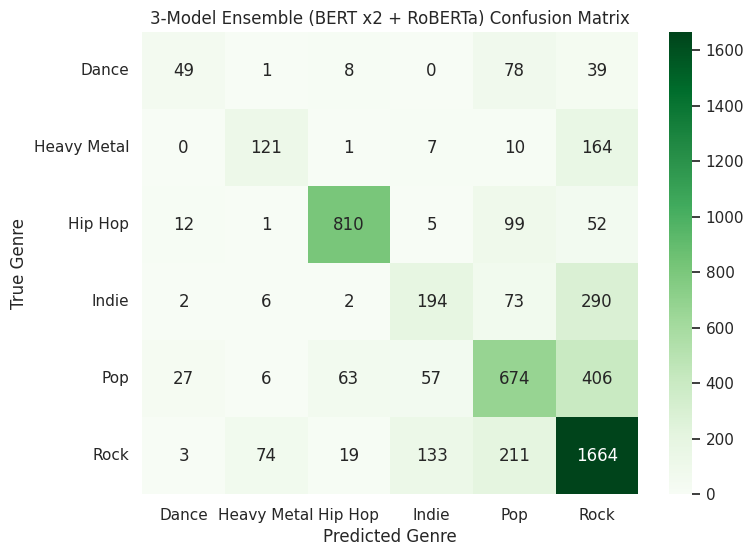

In [34]:
import torch.nn.functional as F                                                                                                                                                                        
import torch                                                                                                                                                                                           
import numpy as np                                                                                                                                                                                     
from sklearn.metrics import classification_report, confusion_matrix                                                                                                                                    
import matplotlib.pyplot as plt                                                                                                                                                                        
import seaborn as sns                                                                                                                                                                                  
                                                                                                                                                                                                       
print("Running 3-Model Ensemble Inference...")                                                                                                                                                         
                                                                                                                                                                                                       
# 1. Extract raw predictions from ALL 3 models                                                                                                                                                         
print("Extracting Unweighted BERT predictions...")                                                                                                                                                     
unweighted_preds = unweighted_trainer.predict(test_tokenized)                                                                                                                                          
                                                                                                                                                                                                       
print("Extracting Weighted BERT predictions...")                                                                                                                                                       
weighted_preds = weighted_trainer.predict(test_tokenized)                                                                                                                                              
                                                                                                                                                                                                       
print("Extracting Weighted RoBERTa predictions...")                                                                                                                                                    
roberta_preds = roberta_trainer.predict(test_roberta)                                                                                                                                                  
                                                                                                                                                                                                       
# 2. Convert raw logits to probabilities using Softmax                                                                                                                                                 
unweighted_probs = F.softmax(torch.tensor(unweighted_preds.predictions), dim=-1).numpy()                                                                                                               
weighted_probs = F.softmax(torch.tensor(weighted_preds.predictions), dim=-1).numpy()                                                                                                                   
roberta_probs = F.softmax(torch.tensor(roberta_preds.predictions), dim=-1).numpy()                                                                                                                     
                                                                                                                                                                                                       
# 3. Average the probabilities across the THREE models                                                                                                                                    
ensemble_probs = (unweighted_probs + weighted_probs + roberta_probs) / 3.0                                                                                                                             
                                                                                                                                                                                                       
# 4. Final ensemble predictions                                                                                                                                                                        
ensemble_pred_labels = np.argmax(ensemble_probs, axis=1)                                                                                                                                               
                                                                                                                                                                                                       
print(f"\n{'='*20} ULTIMATE 3-MODEL ENSEMBLE TEST REPORT {'='*20}")                                                                                                                                    
print(classification_report(test_true_labels, ensemble_pred_labels, target_names=label_names))                                                                                                         
                                                                                                                                                                                                       
# 5. Plot Ensemble Confusion Matrix                                                                                                                                                                    
plt.figure(figsize=(8, 6))                                                                                                                                                                             
cm_ensemble = confusion_matrix(test_true_labels, ensemble_pred_labels)                                                                                                                                 
sns.heatmap(cm_ensemble, annot=True, fmt='d', cmap='Greens', xticklabels=label_names, yticklabels=label_names)                                                                                         
plt.title('3-Model Ensemble (BERT x2 + RoBERTa) Confusion Matrix')                                                                                                                                     
plt.ylabel('True Genre')                                                                                                                                                                               
plt.xlabel('Predicted Genre')                                                                                                                                                                          
plt.show()

In [35]:
import os                                                                                                                                                                                              
                                                                                                                                                                                                       
print("Exporting final 3-Model Ensemble for deployment...")                                                                                                                                            
os.makedirs("./deployment_models", exist_ok=True)                                                                                                                                                      
                                                                                                                                                                                                       
# Save the Unweighted BERT model & tokenizer                                                                                                                                                        
unweighted_trainer.save_model("./deployment_models/unweighted_bert")                                                                                                                                   
tokenizer.save_pretrained("./deployment_models/unweighted_bert")                                                                                                                                       
print("Saved Unweighted BERT")                                                                                                                                                                         
                                                                                                                                                                                                       
# Save the Weighted BERT model & tokenizer                                                                                                                                                          
weighted_trainer.save_model("./deployment_models/weighted_bert")                                                                                                                                       
tokenizer.save_pretrained("./deployment_models/weighted_bert")                                                                                                                                         
print("Saved Weighted BERT")                                                                                                                                                                           
                                                                                                                                                                                                       
# Save the Weighted RoBERTa model & tokenizer                                                                                                                                                       
roberta_trainer.save_model("./deployment_models/weighted_roberta")                                                                                                                                     
roberta_tokenizer.save_pretrained("./deployment_models/weighted_roberta")                                                                                                                              
print("Saved Weighted RoBERTa")                                                                                                                                                                        
                                                                                                                                                                                                       
print("All ensemble models successfully exported!")

Exporting final 3-Model Ensemble for deployment...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved Unweighted BERT


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved Weighted BERT


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved Weighted RoBERTa
All ensemble models successfully exported!
